# House Price Prediction using Linear Regression

## 1. Exploratory Data Analysis

This section performs an initial exploration of the house price dataset to understand its structure, data types, missing values, and basic statistical characteristics.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import Dataset
df = pd.read_csv("C:/Users/salon/OneDrive/Documents/DataAnalytics-L2-T1-HousePricePrediction/Dataset/House Price Prediction Dataset.csv")

#Check first Five rows
df.head(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
#Check the number of rows and columns
df.shape

(2000, 10)

In [4]:
#Check the information about rows , columns , not-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [5]:
# Check missing values in each column
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [6]:
#Check for duplicated records
df.duplicated().sum()


np.int64(0)

In [7]:
#Generate descriptive Statistics for numerical columns
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


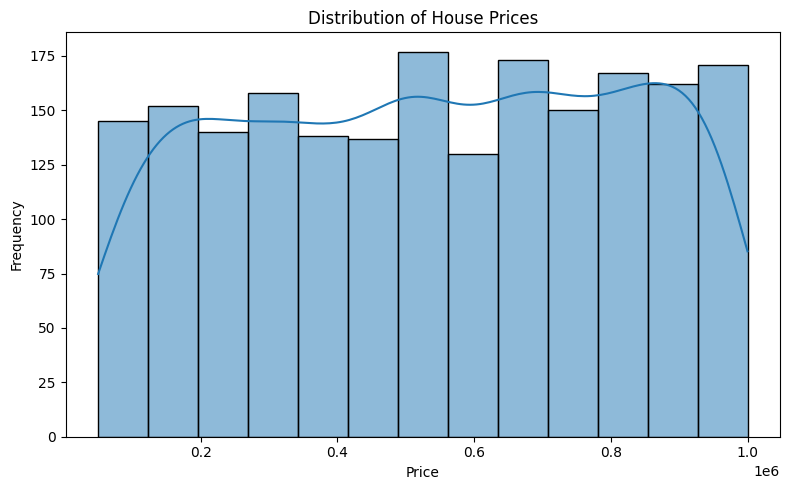

In [8]:
# Plot the distribution of house prices

plt.figure(figsize=(8, 5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Observation

The price distribution shows how house prices are spread across the dataset. It helps identify the most common price range and whether the dataset contains relatively high-priced or low-priced properties.

## 2. Feature Selection Discussion

The target variable for this project is `Price`, as the objective is to predict house prices.

The following features are considered potential predictors of house price:

- **Area:** Larger properties generally provide more living space and may have higher prices.
- **Bedrooms:** The number of bedrooms can influence the value of a house because properties with more bedrooms may be more suitable for families.
- **Bathrooms:** Houses with more bathrooms may have greater utility and can therefore have higher prices.
- **Floors:** The number of floors can affect the amount of usable space and may influence house prices.
- **YearBuilt:** The age of a property can affect its value. Newer houses may have better construction and modern features.
- **Location:** Location is an important factor in determining property prices because different locations can have different levels of demand and market value.
- **Condition:** The condition of a house can influence its market value, with better-maintained properties generally being more desirable.
- **Garage:** The availability of a garage can add value because it provides parking and additional storage space.

Therefore, these features will be considered as predictors for the Linear Regression model, while `Price` will be used as the target variable.

In [10]:
# Display all columns in the dataset

df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')

## 3. Data Preprocessing

In this section, missing values are handled and categorical features are converted into numerical features using One-Hot Encoding. This preprocessing is necessary because the Linear Regression model requires numerical input features.

In [15]:
# Handle missing values in numerical columns using median

numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns] = df[numerical_columns].fillna(
    df[numerical_columns].median()
)

In [16]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include=["str"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Location', 'Condition', 'Garage'], dtype='str')


In [17]:
# Convert categorical features into numerical features using One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

# Display the first five rows
df_encoded.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [18]:
# Display the columns after One-Hot Encoding

print(df_encoded.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


In [19]:
# Check data types after encoding

df_encoded.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 2000 non-null   int64
 1   Area               2000 non-null   int64
 2   Bedrooms           2000 non-null   int64
 3   Bathrooms          2000 non-null   int64
 4   Floors             2000 non-null   int64
 5   YearBuilt          2000 non-null   int64
 6   Price              2000 non-null   int64
 7   Location_Rural     2000 non-null   bool 
 8   Location_Suburban  2000 non-null   bool 
 9   Location_Urban     2000 non-null   bool 
 10  Condition_Fair     2000 non-null   bool 
 11  Condition_Good     2000 non-null   bool 
 12  Condition_Poor     2000 non-null   bool 
 13  Garage_Yes         2000 non-null   bool 
dtypes: bool(7), int64(7)
memory usage: 123.2 KB


## Observation

The dataset was checked for missing values and appropriate handling was applied to numerical columns. The categorical features were converted into numerical variables using One-Hot Encoding so that they can be used by the Linear Regression model.

## 4. Correlation Analysis

Correlation analysis is used to identify the strength and direction of relationships between numerical variables. In particular, the correlation with `Price` helps identify which numerical features may be useful predictors of house prices.

In [23]:
# Calculate the correlation matrix for all numerical variables
# The correlation coefficient ranges from -1 to +1:
# +1 indicates a strong positive relationship
# -1 indicates a strong negative relationship
#  0 indicates little or no linear relationship

correlation_matrix = df_encoded.corr(numeric_only=True)

# Display the correlation matrix
correlation_matrix

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643,0.006647,-0.044954,0.016093,-0.007459,-0.025798,0.034609,0.001199
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542,-0.017328,0.003404,0.000010,0.012805,0.001289,-0.003387,-0.003441
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471,-0.011276,-0.010409,0.025640,0.002541,-0.008847,0.010673,-0.041713
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737,-0.020028,-0.000904,-0.007326,-0.029646,0.021735,0.013355,0.004057
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890,-0.007149,-0.009907,0.014640,-0.000864,0.001462,0.017469,-0.004635
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845,-0.009179,-0.004632,-0.029859,-0.039087,0.022457,0.020892,-0.011703
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000,0.001890,0.040303,-0.038312,0.049218,-0.017179,-0.018437,0.002842
Location_Rural,0.006647,-0.017328,-0.011276,-0.020028,-0.007149,-0.009179,0.001890,1.000000,-0.314480,-0.315338,0.022832,-0.025844,0.004976,0.028254
Location_Suburban,-0.044954,0.003404,-0.010409,-0.000904,-0.009907,-0.004632,0.040303,-0.314480,1.000000,-0.319261,0.003137,-0.000920,0.001503,0.027303
Location_Urban,0.016093,0.000010,0.025640,-0.007326,0.014640,-0.029859,-0.038312,-0.315338,-0.319261,1.000000,-0.003568,0.006115,0.018913,-0.010005


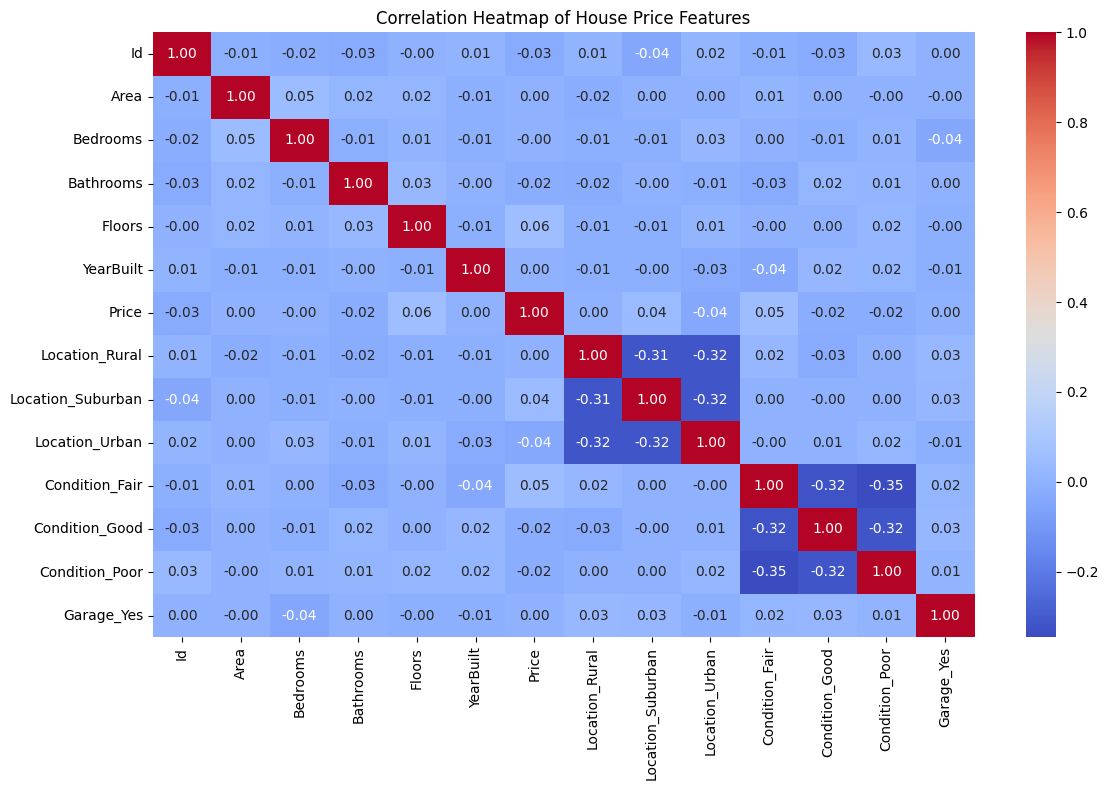

In [24]:
# Create a figure for the correlation heatmap
plt.figure(figsize=(12, 8))

# Plot the correlation matrix as a heatmap
# annot=True displays the correlation values inside the cells
# cmap="coolwarm" makes positive and negative correlations easier to identify
# fmt=".2f" displays correlation values up to two decimal places

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add a title to the heatmap
plt.title("Correlation Heatmap of House Price Features")

# Adjust the layout so labels are displayed properly
plt.tight_layout()

# Display the heatmap
plt.show()

In [25]:
# Extract the correlation values of all numerical features with the target variable Price
price_correlation = correlation_matrix["Price"]

# Sort the correlation values from highest to lowest
price_correlation = price_correlation.sort_values(ascending=False)

# Display the correlation of each feature with Price
print("Correlation with Price:")
print(price_correlation)

Correlation with Price:
Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64


## Observation

The correlation analysis shows that `Floors` has the strongest positive correlation with `Price` among the numerical variables, with a correlation of approximately 0.056.

`Condition_Fair` and `Location_Suburban` also show small positive correlations with `Price`.

On the other hand, `Condition_Poor`, `Location_Urban`, and `Id` show small negative correlations with `Price`.

Overall, all correlation values are close to zero, indicating that none of the individual numerical features has a strong linear relationship with house price in this dataset. Therefore, multiple features will be considered together when building the Linear Regression model.

## 5. Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

The training set will be used to train the Linear Regression model, while the testing set will be used to evaluate how well the model performs on unseen data.

In [35]:
# Separate the independent features from the target variable

X = df_encoded.drop("Price", axis=1)

# Store the target variable separately
y = df_encoded["Price"]

# Display the shape of features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 13)
Target shape: (2000,)


In [36]:
# Import train_test_split function from scikit-learn

from sklearn.model_selection import train_test_split

In [37]:
# Split the dataset into 80% training data and 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shape of each dataset

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1600, 13)
Testing features: (400, 13)
Training target: (1600,)
Testing target: (400,)


## Observation

The dataset was successfully divided into 80% training data and 20% testing data. The training set will be used to build the Linear Regression model, while the testing set will be used to evaluate its performance on unseen data.

## 6. Train Linear Regression Model

A Linear Regression model is trained using the training dataset. The model learns the relationship between the selected house features and the target variable `Price`.

In [38]:
# Import the Linear Regression model from scikit-learn

from sklearn.linear_model import LinearRegression

In [39]:
# Create an instance of the Linear Regression model

linear_model = LinearRegression()

In [40]:
# Train the Linear Regression model using the training data

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ -12.01, -0.48, 53.25,...,-13048.18, 4389.78, 2218.65]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Id','Area','Bedrooms',...,'Condition_Good','Condition_Poor','Garage_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.927e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [41]:
# Display the intercept of the trained Linear Regression model

print("Model Intercept:", linear_model.intercept_)

Model Intercept: 292657.05797355756


## Observation

The Linear Regression model was successfully trained using the 80% training dataset. The model has learned the relationship between the selected house features and house prices and can now be used to make predictions on the testing dataset.

## 7. Model Evaluation

The trained Linear Regression model is evaluated on the testing dataset using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

MSE and RMSE measure the prediction error, where lower values indicate better performance. R² Score measures how well the model explains the variation in house prices, with a higher value generally indicating better performance.

In [42]:
# Use the trained Linear Regression model to predict house prices
# for the unseen testing data

y_pred = linear_model.predict(X_test)

# Display the first five predicted prices
print("First five predicted prices:")
print(y_pred[:5])

First five predicted prices:
[511317.73109931 557359.55652936 482838.34523391 540695.6411198
 549288.50244107]


In [43]:
# Import evaluation metrics from scikit-learn

from sklearn.metrics import mean_squared_error, r2_score

In [44]:
# Calculate Mean Squared Error (MSE)

mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
# RMSE is the square root of MSE

rmse = np.sqrt(mse)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 78279764120.86241
Root Mean Squared Error (RMSE): 279785.2106900263
R² Score: -0.006181784611834162


## 8. Actual vs Predicted Prices

The actual house prices are compared with the prices predicted by the Linear Regression model. A scatter plot is used to visualize the relationship between actual and predicted prices.

If the predictions are accurate, the points should lie close to the diagonal reference line.

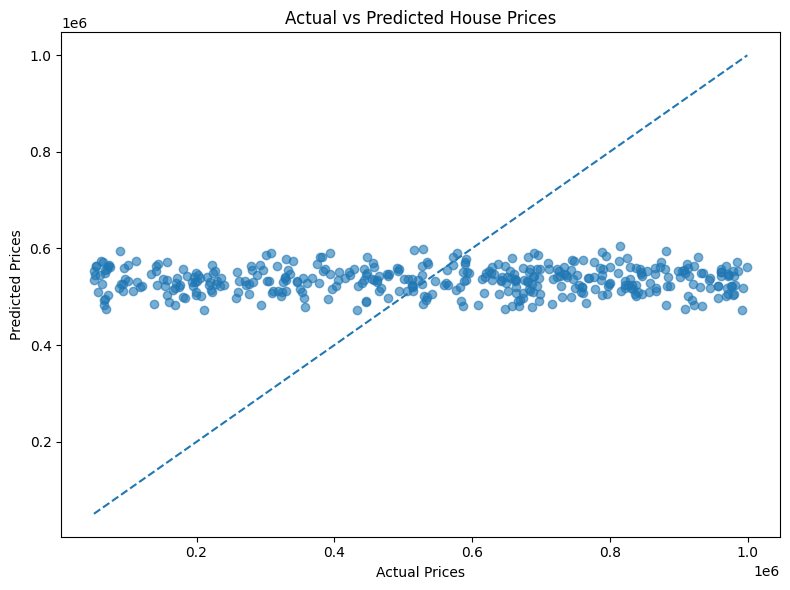

In [45]:
# Create a scatter plot of actual prices against predicted prices

plt.figure(figsize=(8, 6))

# Plot actual prices on the x-axis and predicted prices on the y-axis
plt.scatter(y_test, y_pred, alpha=0.6)

# Create a diagonal reference line
# Points closer to this line indicate more accurate predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

# Add title and axis labels
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()

## Observation

The scatter plot shows that the predicted prices are mostly concentrated around a narrow range, while the actual prices are spread across a much wider range.

Many points are far away from the diagonal reference line, indicating that the Linear Regression model is not predicting the house prices accurately for many observations.

The model appears to have difficulty capturing the variation in house prices, particularly for houses with very low or very high actual prices.

## 9. Residual Analysis

Residual analysis is used to examine the prediction errors of the Linear Regression model.

Residuals are calculated as the difference between the actual prices and the predicted prices. Ideally, residuals should be randomly scattered around zero without any clear pattern.

In [47]:
# Calculate the residuals by subtracting predicted prices from actual prices

residuals = y_test - y_pred

# Display the first five residual values

print("First five residuals:")
print(residuals.head())

First five residuals:
1860      3446.268901
353     136896.443471
1333   -416463.345234
905     109547.358880
1289   -326003.502441
Name: Price, dtype: float64


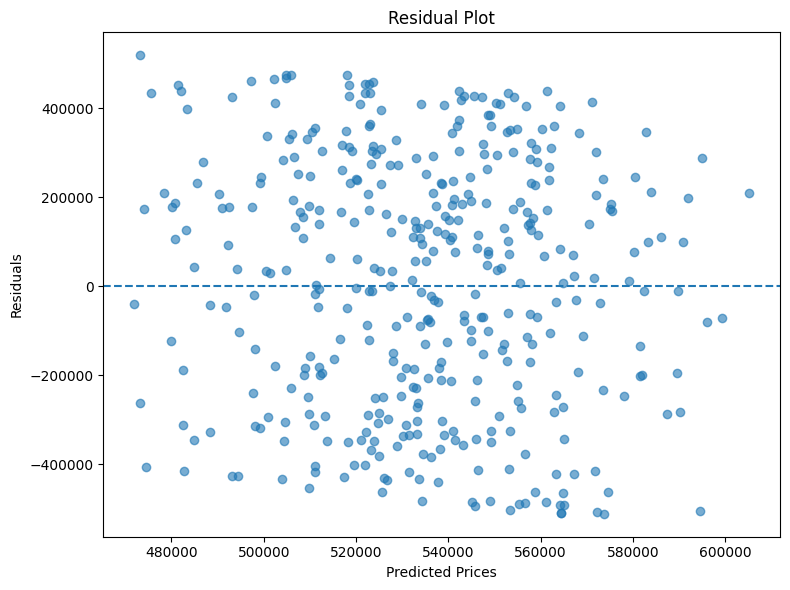

In [48]:
# Create a residual plot

plt.figure(figsize=(8, 6))

# Plot predicted prices against residuals
plt.scatter(y_pred, residuals, alpha=0.6)

# Add a horizontal reference line at zero
# This helps us see whether residuals are centered around zero
plt.axhline(y=0, linestyle="--")

# Add title and axis labels
plt.title("Residual Plot")
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()

## Observation

The residuals are distributed on both sides of the zero reference line, indicating that the model makes both overpredictions and underpredictions.

However, the residuals show a wide spread, with several observations having large positive and negative errors. This indicates that the Linear Regression model is not able to explain all the variation in house prices effectively.

Overall, the residual plot suggests that the model's predictions contain substantial errors and that other factors may be needed to better explain house price variation.

## 10. Coefficient Analysis

Coefficient analysis helps us understand how each feature influences the predicted house price in the Linear Regression model.

A positive coefficient indicates that an increase in the corresponding feature is associated with an increase in predicted price, while a negative coefficient indicates a decrease in predicted price, keeping other features constant.

In [49]:
# Create a DataFrame containing feature names and their corresponding coefficients

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

# Sort coefficients from highest to lowest

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the coefficients

coefficients

,Feature,Coefficient
9,Condition_Fair,24049.504733
4,Floors,23582.408499
7,Location_Suburban,11110.139855
11,Condition_Poor,4389.783506
12,Garage_Yes,2218.649484
6,Location_Rural,1826.466887
5,YearBuilt,116.775334
2,Bedrooms,53.249124
1,Area,-0.484192
0,Id,-12.007473


In [50]:
# Display the features with the highest positive coefficients

print("Top Positive Coefficients:")
print(coefficients.head(10))

# Display the features with the highest negative coefficients

print("\nTop Negative Coefficients:")
print(coefficients.tail(10))

Top Positive Coefficients:
              Feature   Coefficient
9      Condition_Fair  24049.504733
4              Floors  23582.408499
7   Location_Suburban  11110.139855
11     Condition_Poor   4389.783506
12         Garage_Yes   2218.649484
6      Location_Rural   1826.466887
5           YearBuilt    116.775334
2            Bedrooms     53.249124
1                Area     -0.484192
0                  Id    -12.007473

Top Negative Coefficients:
           Feature   Coefficient
11  Condition_Poor   4389.783506
12      Garage_Yes   2218.649484
6   Location_Rural   1826.466887
5        YearBuilt    116.775334
2         Bedrooms     53.249124
1             Area     -0.484192
0               Id    -12.007473
3        Bathrooms  -9835.704344
8   Location_Urban -12601.589640
10  Condition_Good -13048.175894


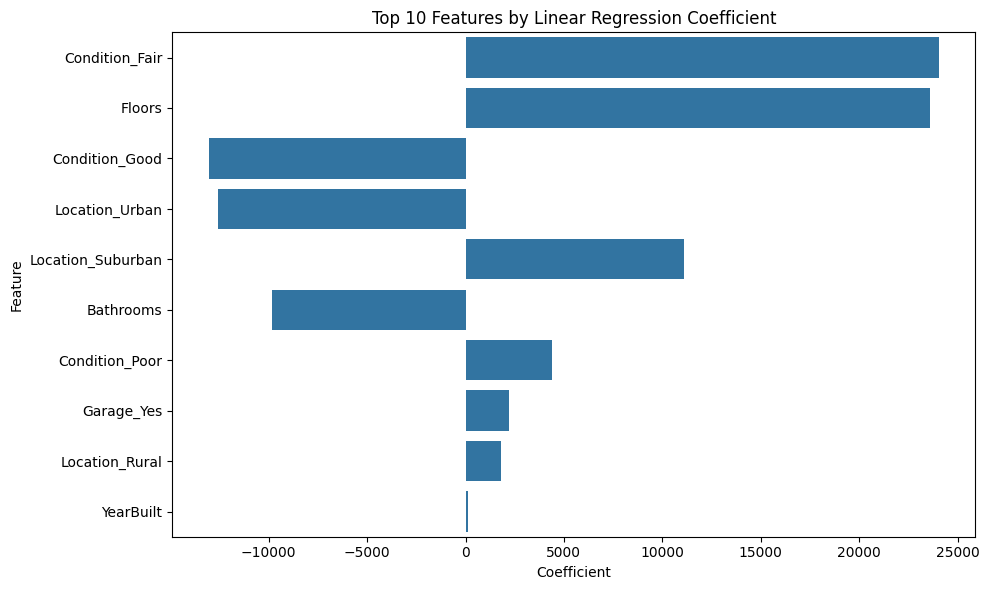

In [51]:
# Select the 10 features with the largest absolute coefficient values

top_coefficients = coefficients.copy()

top_coefficients["Absolute_Coefficient"] = (
    top_coefficients["Coefficient"].abs()
)

top_coefficients = top_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).head(10)

# Create a bar chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

# Add title and labels

plt.title("Top 10 Features by Linear Regression Coefficient")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Observation

The coefficient analysis shows that `Condition_Fair` and `Floors` have the highest positive coefficients, indicating a relatively stronger positive influence on the predicted house price.

Among the negative coefficients, `Condition_Good` has the strongest negative impact, followed by `Location_Urban` and `Bathrooms`.

`YearBuilt`, `Location_Rural`, and `Garage_Yes` have comparatively smaller coefficients, indicating a relatively lower influence on the model's predictions.

Overall, the chart shows that the impact of individual features varies considerably, with `Condition_Fair` and `Floors` having the largest positive coefficients among the features shown.

## 11. Bonus — Ridge Regression Comparison

Ridge Regression is a regularized version of Linear Regression. It adds a penalty to large coefficients, which can help reduce overfitting and improve model stability.

The performance of Ridge Regression will be compared with the Linear Regression model using RMSE and R² Score.

In [52]:
# Import Ridge Regression from scikit-learn

from sklearn.linear_model import Ridge

In [53]:
# Create a Ridge Regression model

ridge_model = Ridge(alpha=1.0)

In [54]:
# Train the Ridge Regression model using the training data

ridge_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [55]:
# Predict house prices using the trained Ridge Regression model

ridge_pred = ridge_model.predict(X_test)

In [56]:
# Calculate Ridge Regression Mean Squared Error

ridge_mse = mean_squared_error(y_test, ridge_pred)

# Calculate Ridge Regression Root Mean Squared Error

ridge_rmse = np.sqrt(ridge_mse)

# Calculate Ridge Regression R² Score

ridge_r2 = r2_score(y_test, ridge_pred)

# Display Ridge Regression performance

print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R² Score:", ridge_r2)

Ridge Regression MSE: 78279532573.56367
Ridge Regression RMSE: 279784.7968949773
Ridge Regression R² Score: -0.006178808380660206


In [57]:
# Create a comparison table for Linear Regression and Ridge Regression

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

# Display the comparison table

model_comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,7.827976e+10,279785.210690,-0.006182
1,Ridge Regression,7.827953e+10,279784.796895,-0.006179


# 13. Conclusion

The house price prediction project used Exploratory Data Analysis, data preprocessing, correlation analysis, and Linear Regression to predict house prices.

The dataset was divided into training and testing sets using an 80/20 split. Categorical features were converted into numerical variables using One-Hot Encoding, and the Linear Regression model was evaluated using MSE, RMSE, and R² Score.

The Actual vs Predicted plot and residual analysis showed how well the model captured the variation in house prices. Coefficient analysis was also performed to identify features with the strongest positive and negative influence on predicted prices.

Overall, the analysis demonstrates that house prices are influenced by multiple features rather than a single variable. The model's performance indicates areas where additional features or more advanced machine learning models could improve prediction accuracy.

## Recommendations

1. **Include more relevant property features:** Additional variables such as property size, neighbourhood quality, renovation status, amenities, and location-specific factors may improve prediction accuracy.

2. **Improve model performance:** Since the Linear Regression model shows considerable prediction errors, other machine learning algorithms such as Random Forest or Gradient Boosting could be tested.

3. **Improve data quality:** Ensuring consistent and complete information for important property characteristics can help the model learn better relationships between features and house prices.

4. **Use model results for pricing decisions:** The model can be used as a baseline tool to estimate house prices and support preliminary pricing and property evaluation decisions.